In [6]:
!pip install sentence-transformers seaborn

In [7]:
sentences = [
# Cricket
"Virat Kohli scored a century in the match",
"The bowler delivered a fast yorker to dismiss the batsman",
"Cricket fans celebrated the team's victory",

# Cooking
"I prepared a delicious pasta with fresh vegetables",
"Baking a chocolate cake requires careful measurement",
"The chef added spices to enhance the flavor",

# Cybersecurity
"Strong passwords help protect online accounts",
"Cybersecurity experts monitor networks for attacks",
"Phishing emails try to steal sensitive information",
"Firewalls help block unauthorized access to systems"
]

print("Total sentences:", len(sentences))

Total sentences: 10


In [8]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

print(embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(10, 384)


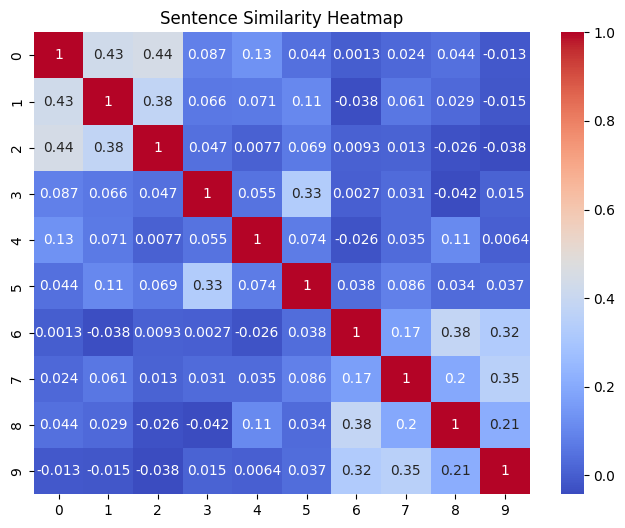

In [9]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=True, cmap="coolwarm")
plt.title("Sentence Similarity Heatmap")
plt.show()

In [10]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

top_indices = similarities.argsort()[-2:][::-1]

for idx in top_indices:
    print("Sentence:", sentences[idx])
    print("Similarity Score:", similarities[idx])
    print()

Sentence: The bowler delivered a fast yorker to dismiss the batsman
Similarity Score: 0.5822266

Sentence: Virat Kohli scored a century in the match
Similarity Score: 0.46225673

